In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
notebook = "real1_Abalone_100_100_long"

Note: in this notebook, we use 5000 burn-in instead of 500 used in other notebooks.

In [3]:
ori_notebook = "real1_Abalone_1_10000"

In [4]:
import numpy as np

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1)

# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets 
X = X.drop(columns=['Sex'])

In [5]:
X = X.values.astype(float)
y = np.array(y).reshape(-1)

In [6]:
ndpost = 100
nskip = 5000 # different from other notebooks
n_chains = 100
n_trees = 20
n_test_points = 100

In [ ]:
from experiment import run_parallel_experiments

# Run parallel chains with temperature schedule
results = run_parallel_experiments(
    X, y, ndpost, nskip, n_trees, notebook,
    tree_alpha=0.95, tree_beta=2.0, m_tries=10,
    n_chains=n_chains, n_jobs=5, store_preds=True,
    n_test_points=n_test_points,  # Store all test points if not specified
    start_temp=1.0, end_temp=1.0
)

In [7]:
import numpy as np

# Load results from the .npz file
data = np.load(f"store/{notebook}.npz", allow_pickle=True)

# Extract results for default and mtmh
default_data = data["default"].item()
mtmh_data = data["mtmh"].item()

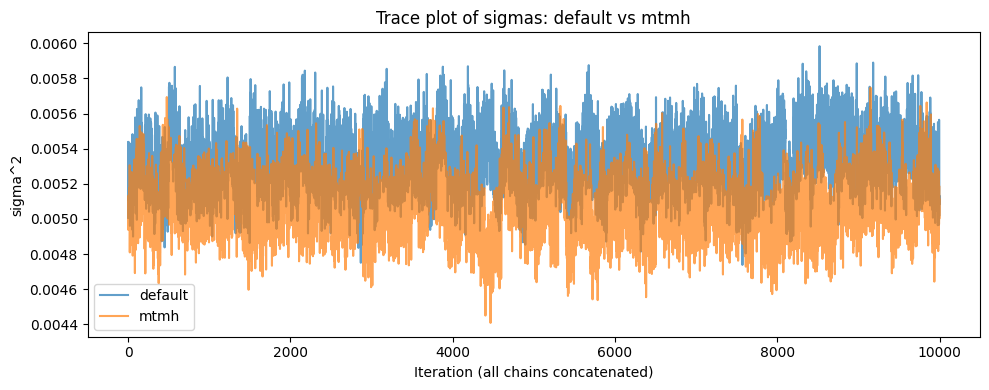

In [8]:
import matplotlib.pyplot as plt

# sigmas shape: (n_chains, ndpost)
sigmas_default = default_data["sigmas"].reshape(-1)
sigmas_mtmh = mtmh_data["sigmas"].reshape(-1)

# trace plot
plt.figure(figsize=(10, 4))
plt.plot(sigmas_default, label="default", alpha=0.7)
plt.plot(sigmas_mtmh, label="mtmh", alpha=0.7)
plt.xlabel("Iteration (all chains concatenated)")
plt.ylabel("sigma^2")
plt.title("Trace plot of sigmas: default vs mtmh")
plt.legend()
plt.tight_layout()
plt.show()

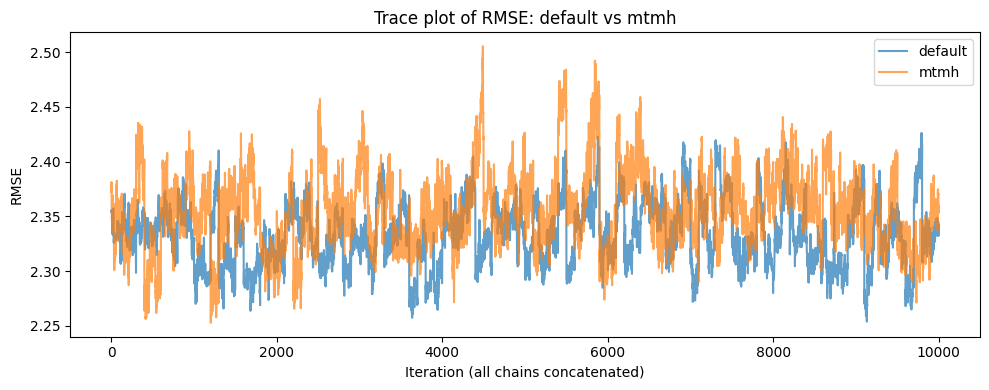

In [9]:
import matplotlib.pyplot as plt

# rmse shape: (n_chains, ndpost)
rmse_default = default_data["rmses"].reshape(-1)
rmse_mtmh = mtmh_data["rmses"].reshape(-1)

# trace plot
plt.figure(figsize=(10, 4))
plt.plot(rmse_default, label="default", alpha=0.7)
plt.plot(rmse_mtmh, label="mtmh", alpha=0.7)
plt.xlabel("Iteration (all chains concatenated)")
plt.ylabel("RMSE")
plt.title("Trace plot of RMSE: default vs mtmh")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
import numpy as np

preds_default = default_data["preds"]      # (n_chains, n_test, ndpost)
preds_mtmh    = mtmh_data["preds"]        # (n_chains, n_test, ndpost)

# Reconstruct the common train/test split (must match experiment.run_chain)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Recreate the subset of test points used for stored preds
n_test_points = 100
rng = np.random.default_rng(42)
if n_test_points is not None and n_test_points < X_test.shape[0]:
    idx = rng.choice(X_test.shape[0], n_test_points, replace=False)
else:
    idx = np.arange(X_test.shape[0])

y_test_sub = y_test[idx]  # shape (n_test_points,)

# preds_default / preds_mtmh shapes: (n_chains, n_test_points, ndpost)
# Average over all chains and ndpost for each test point
mean_preds_default = preds_default.mean(axis=(0, 2))  # shape (n_test_points,)
mean_preds_mtmh    = preds_mtmh.mean(axis=(0, 2))     # shape (n_test_points,)

# Overall RMSE across these test points
rmse_default_mean = root_mean_squared_error(y_test_sub, mean_preds_default)
rmse_mtmh_mean    = root_mean_squared_error(y_test_sub, mean_preds_mtmh)

print(f"RMSE (posterior mean, default): {rmse_default_mean:.4f}")
print(f"RMSE (posterior mean, mtmh):    {rmse_mtmh_mean:.4f}")

RMSE (posterior mean, default): 1.9195
RMSE (posterior mean, mtmh):    1.9293


In [11]:
from sklearn.model_selection import train_test_split
import numpy as np

# Load posterior predictive samples for each method
preds_default = default_data["preds"]   # shape: (n_chains, n_test_points, ndpost)
preds_mtmh    = mtmh_data["preds"]      # shape: (n_chains, n_test_points, ndpost)

# Reconstruct the common train/test split (must match experiment.run_chain)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Number of test points stored in preds
n_chains, n_test_points, ndpost = preds_default.shape

# Recreate the subset of test points used for stored preds (same RNG & seed)
rng = np.random.default_rng(42)
if n_test_points is not None and n_test_points < X_test.shape[0]:
    idx = rng.choice(X_test.shape[0], n_test_points, replace=False)
else:
    idx = np.arange(X_test.shape[0])

y_test_sub = y_test[idx]  # shape (n_test_points,)

def crps_from_samples(samples, y_true):
    """Compute CRPS for scalar outcomes from posterior samples.

    samples: array of shape (n_points, n_samples)
    y_true:  array of shape (n_points,)
    Returns: array of shape (n_points,) with CRPS for each point.
    """
    n_points, n_samples = samples.shape

    # First term: E|X - y|
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)

    # Second term: (1 / (2N^2)) * sum_{i,j} |x_i - x_j|
    # Computed efficiently using sorted samples:
    #   (1 / (2N^2)) * sum_{i,j} |x_i - x_j| = (1 / N^2) * sum_{k}(2k - N - 1) x_(k)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]  # shape (1, n_samples)
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples ** 2)

    return term1 - term2

# Reshape preds so that all chains × ndpost are treated as posterior samples
# For each test point: samples_default[i] has shape (n_chains * ndpost,)
n_chains_d, n_points_d, ndpost_d = preds_default.shape
samples_default = preds_default.transpose(1, 0, 2).reshape(n_points_d, n_chains_d * ndpost_d)

n_chains_m, n_points_m, ndpost_m = preds_mtmh.shape
samples_mtmh = preds_mtmh.transpose(1, 0, 2).reshape(n_points_m, n_chains_m * ndpost_m)

# CRPS per test point
crps_default = crps_from_samples(samples_default, y_test_sub)
crps_mtmh    = crps_from_samples(samples_mtmh, y_test_sub)

print(f"Mean CRPS (default): {crps_default.mean():.6f}")
print(f"Mean CRPS (mtmh):    {crps_mtmh.mean():.6f}")

Mean CRPS (default): 1.237170
Mean CRPS (mtmh):    1.245845


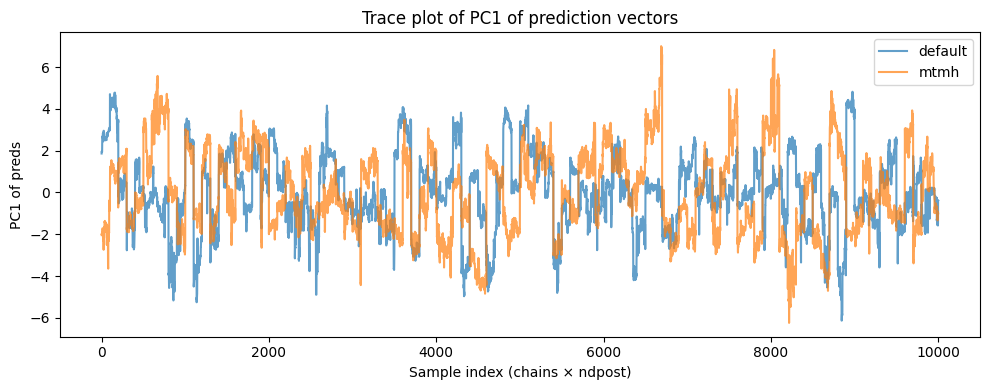

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

preds_default = default_data["preds"]      # (n_chains, n_test, ndpost)
preds_mtmh    = mtmh_data["preds"]        # (n_chains, n_test, ndpost)

# (n_chains, n_test, ndpost) -> (n_chains, ndpost, n_test) -> (n_chains * ndpost, n_test)
def reshape_for_pca(preds):
    n_chains, n_test, ndpost = preds.shape
    return preds.transpose(0, 2, 1).reshape(-1, n_test)

X_default = reshape_for_pca(preds_default)
X_mtmh    = reshape_for_pca(preds_mtmh)

# PCA
pca_default = PCA(n_components=1)
pc1_default = pca_default.fit_transform(X_default)[:, 0]

pca_mtmh = PCA(n_components=1)
pc1_mtmh = pca_mtmh.fit_transform(X_mtmh)[:, 0]

# PC1 trace plot
plt.figure(figsize=(10, 4))
plt.plot(pc1_default, label="default", alpha=0.7)
plt.plot(pc1_mtmh, label="mtmh", alpha=0.7)
plt.xlabel("Sample index (chains × ndpost)")
plt.ylabel("PC1 of preds")
plt.title("Trace plot of PC1 of prediction vectors")
plt.legend()
plt.tight_layout()
plt.show()

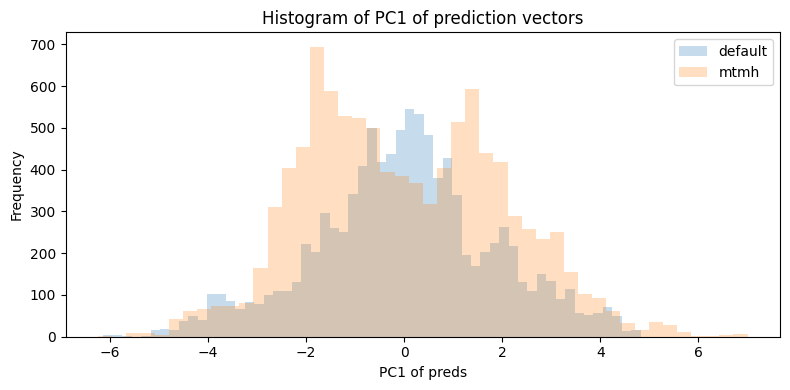

In [13]:
# histogram of PC1
plt.figure(figsize=(8, 4))
plt.hist(pc1_default, bins='auto', alpha=0.25, label="default")
plt.hist(pc1_mtmh, bins='auto', alpha=0.25, label="mtmh")
plt.xlabel("PC1 of preds") 
plt.ylabel("Frequency")
plt.title("Histogram of PC1 of prediction vectors")
plt.legend()
plt.tight_layout()
plt.show()

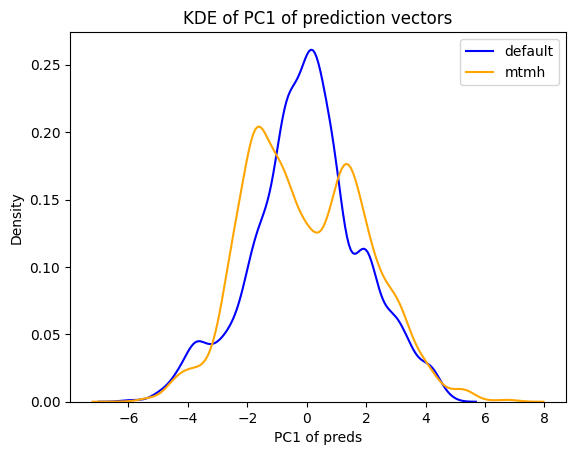

In [14]:
fig, ax = plt.subplots()
import seaborn as sns
sns.kdeplot(pc1_default, label="default", ax=ax, color='blue')
sns.kdeplot(pc1_mtmh, label="mtmh", ax=ax, color='orange')
ax.set_xlabel("PC1 of preds")
ax.set_ylabel("Density")
ax.set_title("KDE of PC1 of prediction vectors")
ax.legend()
plt.show()

# Comparison

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Compare predictions from two experiment outputs:
file_a = f"store/{notebook}.npz"
file_b = f"store/{ori_notebook}.npz"

data_a = np.load(file_a, allow_pickle=True)
data_b = np.load(file_b, allow_pickle=True)

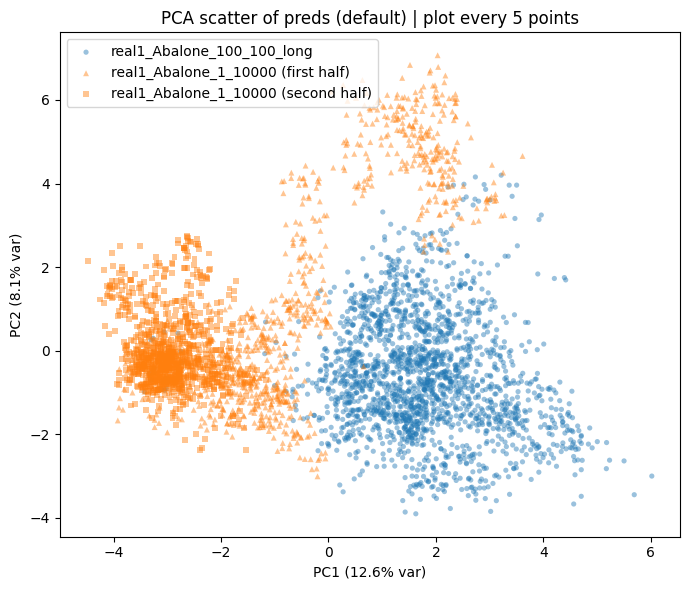

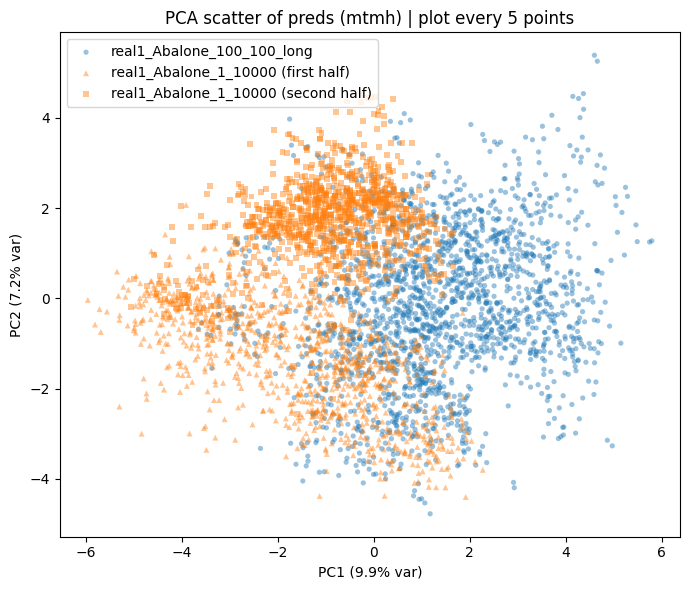

In [16]:
def get_pred_matrix(npz_data, method_key):
    """Return matrix of shape (n_samples, n_test_points) for PCA."""
    preds = npz_data[method_key].item()["preds"]  # (n_chains, n_test, ndpost)
    n_chains, n_test, ndpost = preds.shape
    return preds.transpose(0, 2, 1).reshape(n_chains * ndpost, n_test)


def plot_pca_scatter(method_key, label_a, label_b, plot_step=5):
    Xa = get_pred_matrix(data_a, method_key)
    Xb = get_pred_matrix(data_b, method_key)

    # PCA is still fit on all samples (no downsampling here).
    X = np.vstack([Xa, Xb])
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X)

    n_a = Xa.shape[0]
    n_b = Xb.shape[0]
    b_start = n_a
    b_mid = b_start + n_b // 2
    b_end = b_start + n_b

    plt.figure(figsize=(7, 6))

    # Downsample only for plotting: take every `plot_step` points.
    idx_a = np.arange(0, n_a, plot_step)
    idx_b_first = np.arange(b_start, b_mid, plot_step)
    idx_b_second = np.arange(b_mid, b_end, plot_step)

    # notebook points
    plt.scatter(
        pcs[idx_a, 0],
        pcs[idx_a, 1],
        s=14,
        alpha=0.45,
        label=label_a,
        c="tab:blue",
        marker="o",
        edgecolors="none"
    )

    # ori_notebook first half and second half: same color, different markers
    plt.scatter(
        pcs[idx_b_first, 0],
        pcs[idx_b_first, 1],
        s=18,
        alpha=0.45,
        label=f"{label_b} (first half)",
        c="tab:orange",
        marker="^",
        edgecolors="none"
    )
    plt.scatter(
        pcs[idx_b_second, 0],
        pcs[idx_b_second, 1],
        s=18,
        alpha=0.45,
        label=f"{label_b} (second half)",
        c="tab:orange",
        marker="s",
        edgecolors="none"
    )

    evr = pca.explained_variance_ratio_
    plt.xlabel(f"PC1 ({evr[0] * 100:.1f}% var)")
    plt.ylabel(f"PC2 ({evr[1] * 100:.1f}% var)")
    plt.title(f"PCA scatter of preds ({method_key}) | plot every {plot_step} points")
    plt.legend()
    plt.tight_layout()
    plt.show()


label_a = notebook
label_b = ori_notebook

# 1) default: notebook A vs notebook B
plot_pca_scatter("default", label_a, label_b, plot_step=5)

# 2) mtmh: notebook A vs notebook B
plot_pca_scatter("mtmh", label_a, label_b, plot_step=5)

In [17]:
notebook1 = "real1_Abalone_1_10000"
notebook2 = "real1_Abalone_100_100"
notebook3 = "real1_Abalone_1000_10"
notebook4 = "real1_Abalone_100_100_long"
notebook5 = "real1_Abalone_20_500"

In [18]:
# Reconstruct the common train/test split (must match experiment.run_chain)
_, X_test, _, y_test = train_test_split(X, y, random_state=42)

# Recreate the subset of test points used for stored preds (same RNG & seed)
rng = np.random.default_rng(42)
if n_test_points is not None and n_test_points < X_test.shape[0]:
    idx = rng.choice(X_test.shape[0], n_test_points, replace=False)
else:
    idx = np.arange(X_test.shape[0])
y_test_sub = y_test[idx]

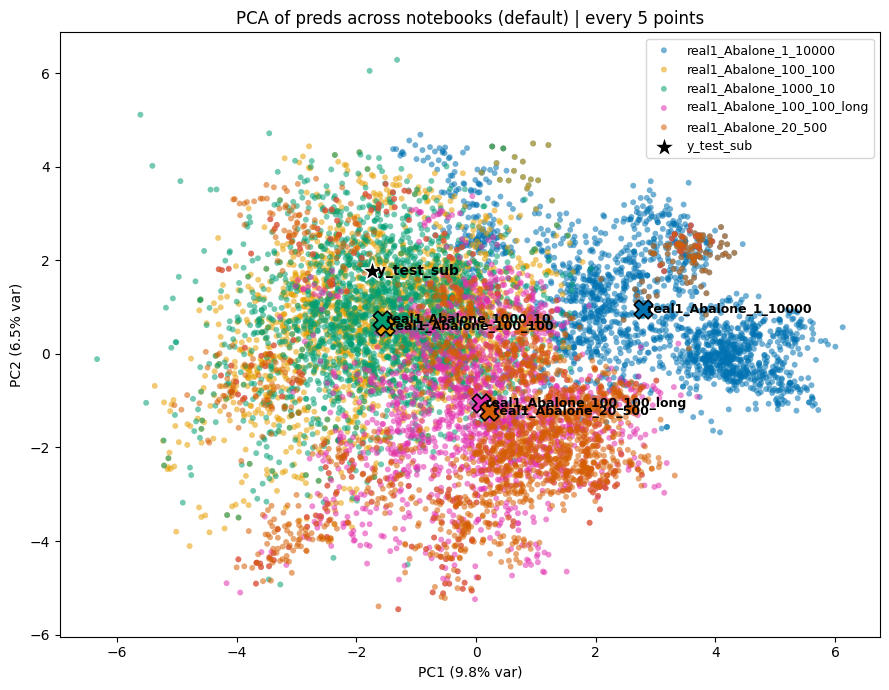

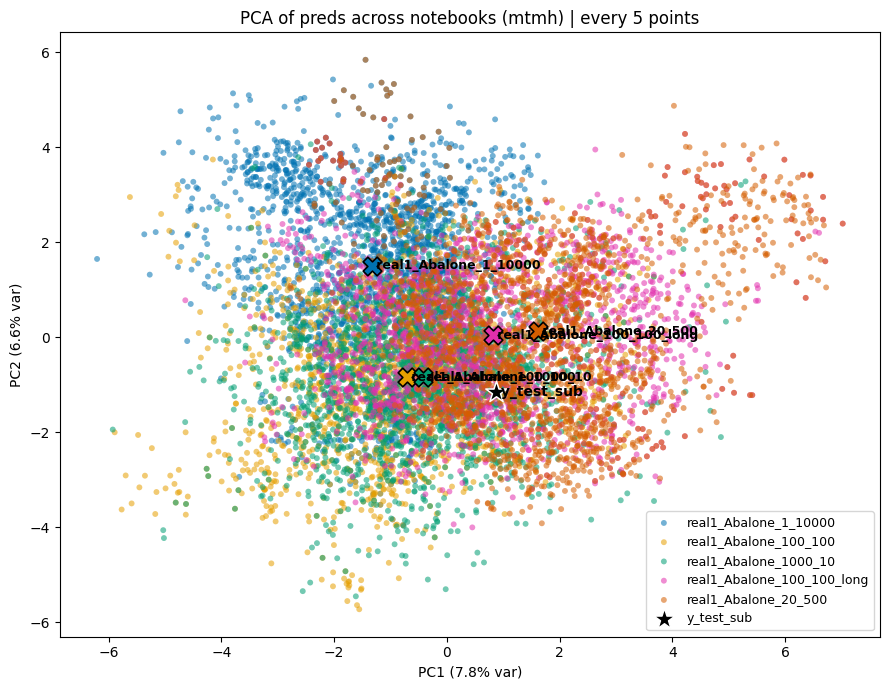

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def preds_to_matrix(npz_data, method_key):
    """Convert preds to shape (n_samples, n_test_points) for PCA."""
    preds = npz_data[method_key].item()["preds"]  # (n_chains, n_test, ndpost)
    n_chains, n_test, ndpost = preds.shape
    return preds.transpose(0, 2, 1).reshape(n_chains * ndpost, n_test)

def get_distinct_colors(n):
    """Return high-contrast colors for a small number of groups."""
    # Colorblind-friendly, high-separation palette (up to 5 groups).
    base_colors = ["#0072B2", "#E69F00", "#009E73", "#E22FAD", "#D55E00"]
    if n <= len(base_colors):
        return base_colors[:n]

    # Fallback for unexpected larger n.
    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(n)]

def plot_notebooks_pca(
    notebook_names,
    method_key,
    plot_step=5,
    mark_centroid=True,
    y_ref=None,
    y_ref_label="y_test_sub",
):
    mats = []
    labels = []

    for name in notebook_names:
        data = np.load(f"store/{name}.npz", allow_pickle=True)
        mats.append(preds_to_matrix(data, method_key))
        labels.append(name)

    X_all = np.vstack(mats)
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_all)

    plt.figure(figsize=(9, 7))
    colors = get_distinct_colors(len(labels))

    start = 0
    for i, (mat, label) in enumerate(zip(mats, labels)):
        n = mat.shape[0]
        segment = pcs[start:start + n]
        idx = np.arange(0, n, plot_step)

        # Scatter downsampled points for readability.
        plt.scatter(
            segment[idx, 0],
            segment[idx, 1],
            s=18,
            alpha=0.55,
            label=label,
            c=[colors[i]],
            edgecolors="none"
        )

        if mark_centroid:
            centroid = segment.mean(axis=0)
            plt.scatter(
                centroid[0],
                centroid[1],
                s=180,
                c=[colors[i]],
                marker="X",
                edgecolors="black",
                linewidths=1.2,
                zorder=5
            )
            plt.text(
                centroid[0],
                centroid[1],
                f" {label}",
                fontsize=9,
                weight="bold",
                va="center",
                ha="left",
                zorder=6
            )

        start += n

    # Project y_test_sub (or any reference vector) into the same PCA plane.
    if y_ref is not None:
        y_ref = np.asarray(y_ref).reshape(1, -1)
        if y_ref.shape[1] != X_all.shape[1]:
            raise ValueError(
                f"y_ref has length {y_ref.shape[1]}, but PCA expects {X_all.shape[1]} features."
            )
        y_proj = pca.transform(y_ref)[0]
        plt.scatter(
            y_proj[0],
            y_proj[1],
            s=260,
            c="black",
            marker="*",
            edgecolors="white",
            linewidths=1.1,
            zorder=8,
            label=y_ref_label
        )
        plt.text(
            y_proj[0],
            y_proj[1],
            f" {y_ref_label}",
            fontsize=10,
            color="black",
            weight="bold",
            va="center",
            ha="left",
            zorder=9
        )

    evr = pca.explained_variance_ratio_
    plt.xlabel(f"PC1 ({evr[0] * 100:.1f}% var)")
    plt.ylabel(f"PC2 ({evr[1] * 100:.1f}% var)")
    plt.title(f"PCA of preds across notebooks ({method_key}) | every {plot_step} points")
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

# Put any number of notebooks here.
notebooks = [notebook1, notebook2, notebook3, notebook4, notebook5]

# default and mtmh are plotted separately, with y_test_sub projected onto each PCA plane.
plot_notebooks_pca(
    notebooks, method_key="default", plot_step=5, mark_centroid=True,
    y_ref=y_test_sub, y_ref_label="y_test_sub"
 )
plot_notebooks_pca(
    notebooks, method_key="mtmh", plot_step=5, mark_centroid=True,
    y_ref=y_test_sub, y_ref_label="y_test_sub"
 )